In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

Loading the data and getting familiar with it.

In [3]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Extracting trend, seasonality and residuals from the time series data.

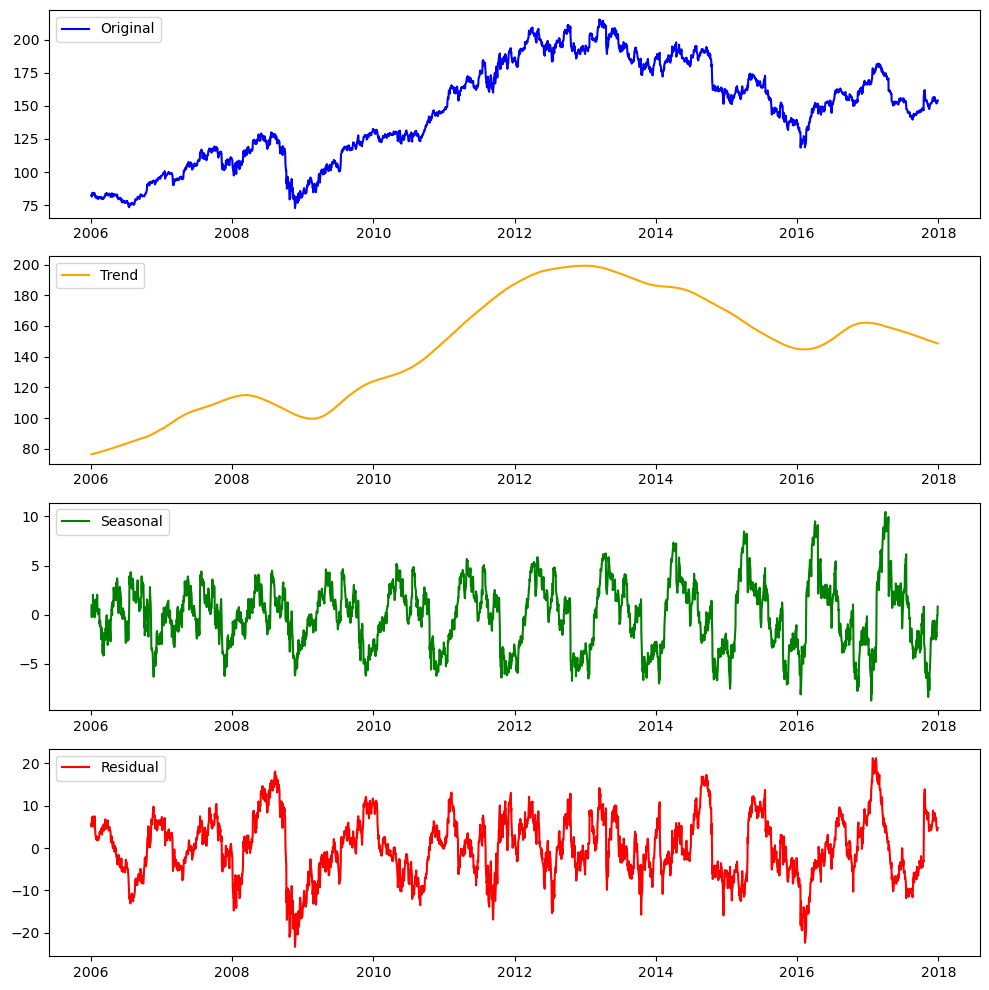

In [4]:
# drop missing values and provide an explicit period so STL doesn't need to infer it from the index
dates = pd.to_datetime(df['Date'])
series = df["Open"]

series = series.dropna()
dates = dates[series.index]

stl = STL(series, period=252, seasonal=17)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(dates, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(dates, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(dates, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(dates, resid, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Autocorrelation analysis

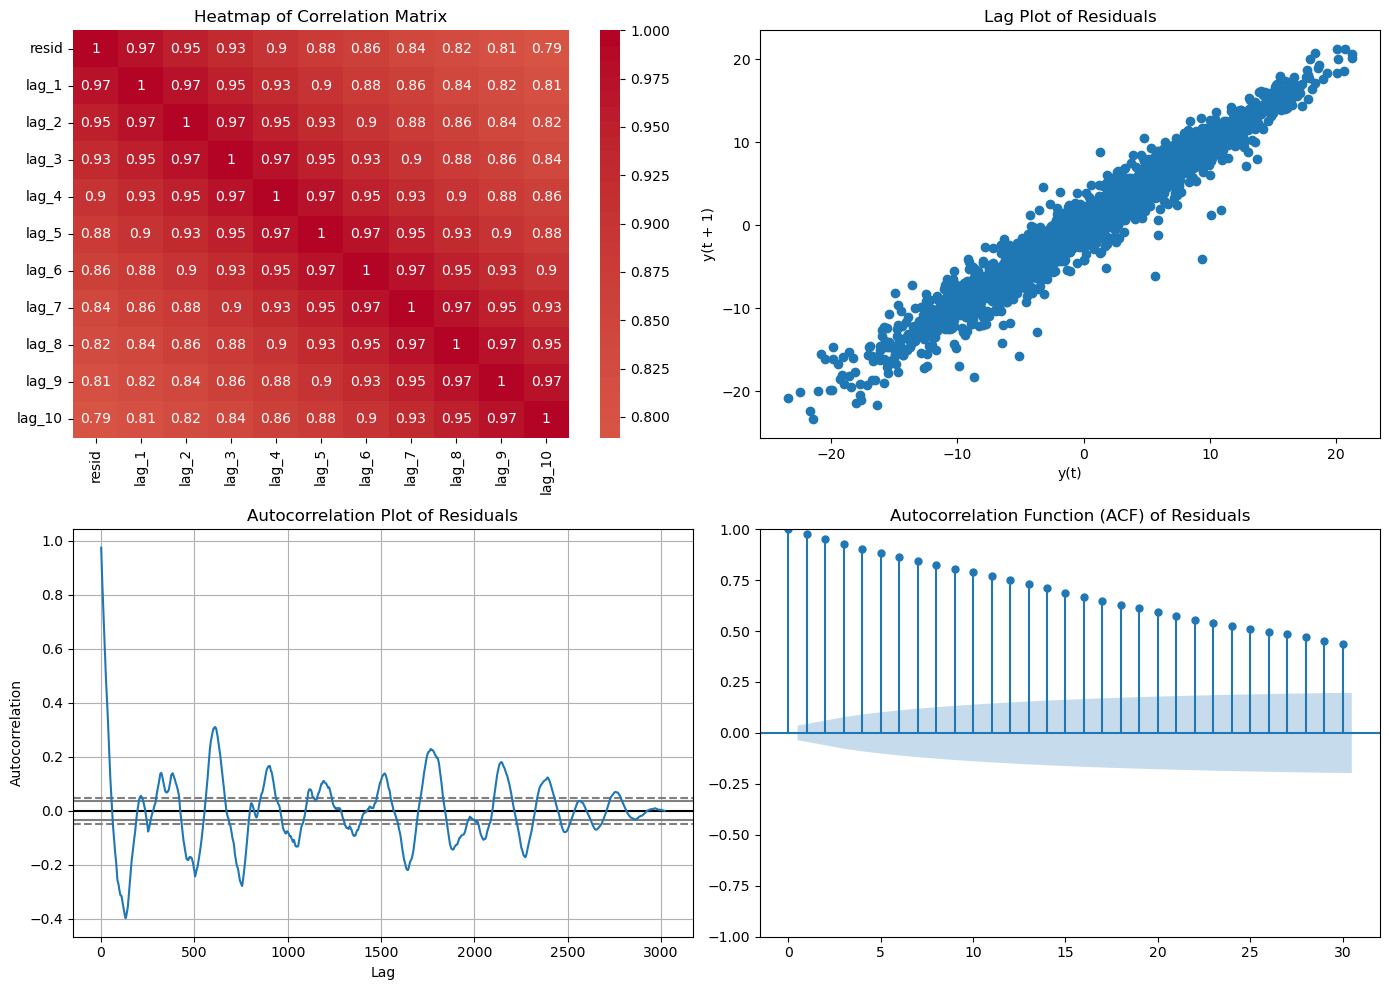

In [ ]:
# Create a 1-10 day lagged dataset of the residuals
lagged_resid = pd.DataFrame({'resid': resid})
for i in range(1, 11):
    lagged_resid[f'lag_{i}'] = lagged_resid['resid'].shift(i)
lagged_resid = lagged_resid.dropna()

# Compute the correlation matrix
corr = lagged_resid.corr()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix')

# Lag plot
pd.plotting.lag_plot(resid, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Residuals')

# Autocorrelation plot
pd.plotting.autocorrelation_plot(resid, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Residuals')

# ACF (from statsmodels)
plot_acf(resid, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Residuals')

plt.tight_layout()
plt.show()


Analyze returns

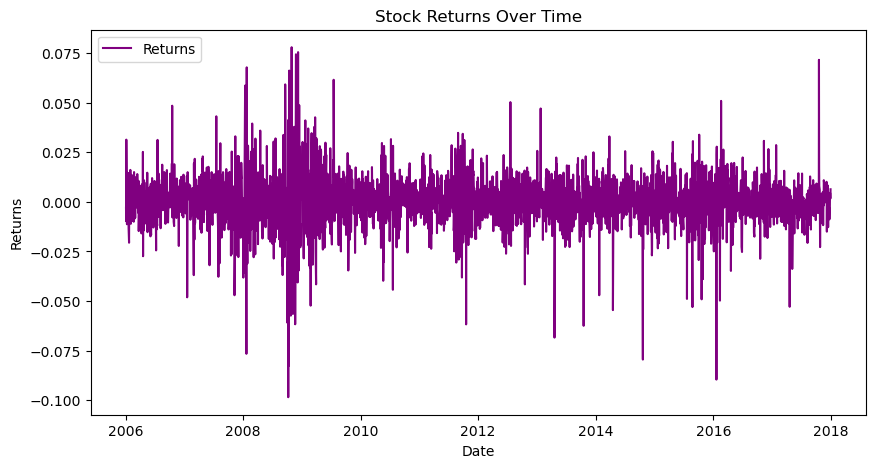

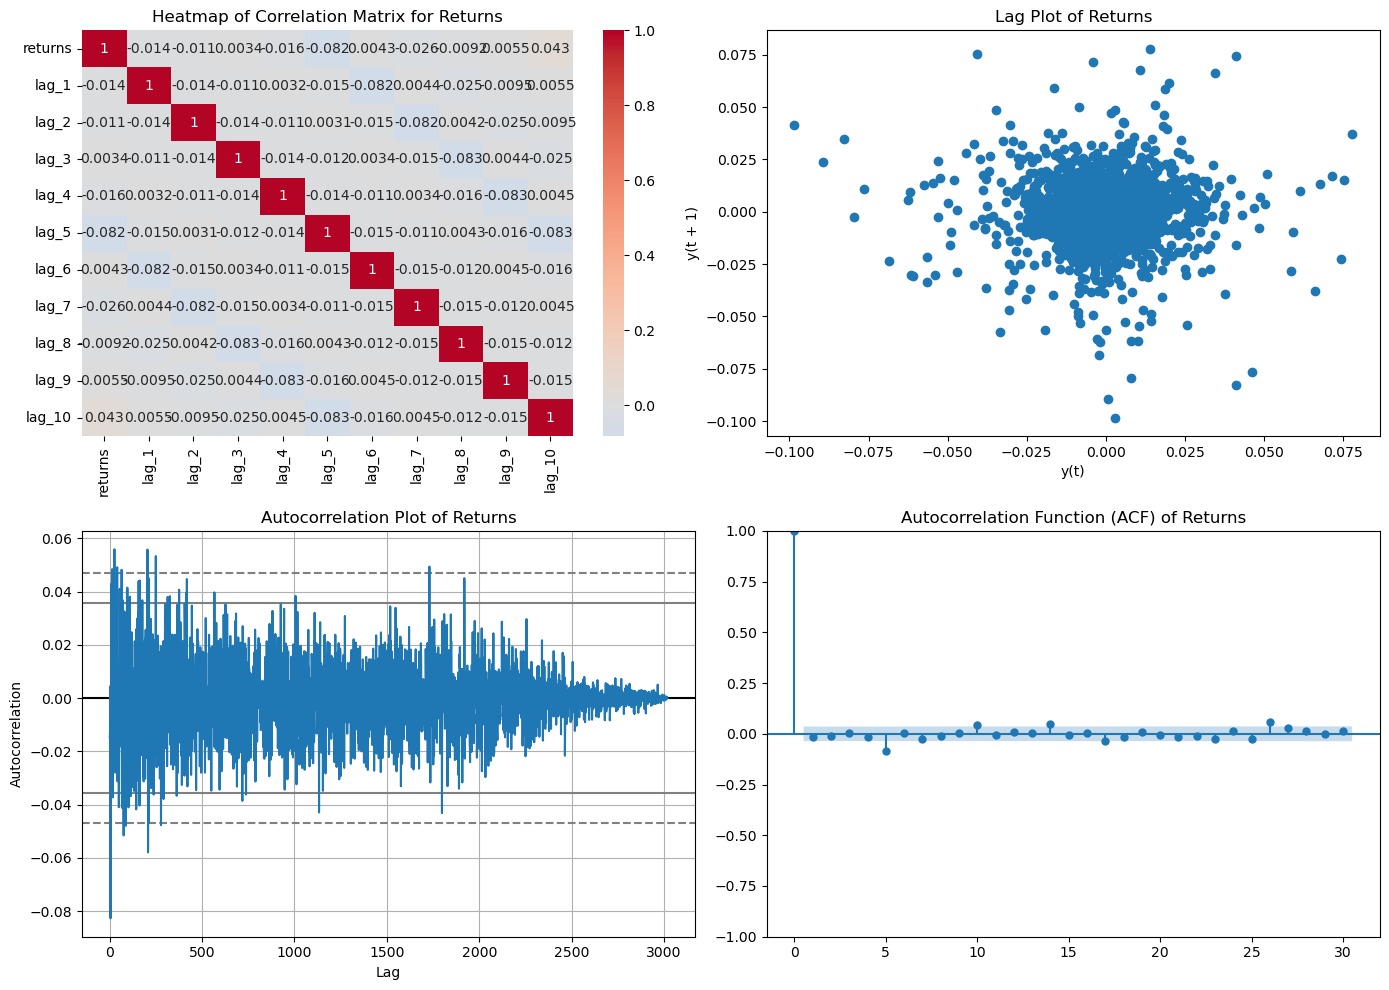

In [22]:
# Calculate returns
returns = series.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.plot(dates[1:], returns, label='Returns', color='purple')
plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Autocorrelation of returns
# Create a 1-10 day lagged dataset
lagged_returns = pd.DataFrame({'returns': returns})
for i in range(1, 11):
    lagged_returns[f'lag_{i}'] = lagged_returns['returns'].shift(i)
lagged_returns = lagged_returns.dropna()

# Compute the correlation matrix
corr_returns = lagged_returns.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Heatmap
sns.heatmap(corr_returns, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix for Returns')
# Lag plot
pd.plotting.lag_plot(returns, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Returns')
# Autocorrelation plot
pd.plotting.autocorrelation_plot(returns, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Returns')
# ACF (from statsmodels)
plot_acf(returns, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Returns')
plt.tight_layout()
plt.show()